# 02 — EDA: V5 Macro Features (Stage 2 Pretrain)

**BBL514E Pattern Recognition — Term Project**

V5 macro feature set (Stage 2 pretrain CSV, 6783 daily rows, Jan 2000 → Dec 2025):

12 derived features:
- VIX raw + VIX z-score (long, expanding window)
- DXY z-score (long)
- SP500_log_return_5d (5-day momentum)
- Gold_log_return_20d, Oil_log_return_20d (commodities)
- FEDFUNDS_change_60d (rate change)
- UNRATE_change_180d (unemployment trend)
- CPI_yoy_change, M2_yoy_change (monetary YoY)
- Yield_Curve_10Y_2Y (recession proxy)
- Gold_Silver_Ratio (risk barometer)

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
proc = PROJECT_ROOT / "data" / "processed"

pretrain = pd.read_csv(proc / "macro_derived_pretrain_v5.csv", index_col=0, parse_dates=True)
print(f"Shape: {pretrain.shape}")
print(f"Span:  {pretrain.index.min().date()} -> {pretrain.index.max().date()}")
pretrain.describe().T[["mean", "std", "min", "max"]].round(3)

Shape: (6783, 12)
Span:  2000-01-03 -> 2025-12-31


,mean,std,min,max
VIX,19.809,8.336,9.140,82.690
VIX_zscore_long,0.000,1.000,-1.280,7.543
DXY_zscore_long,0.000,1.000,-1.909,2.484
SP500_log_return_5d,0.001,0.024,-0.203,0.165
Gold_log_return_20d,0.008,0.045,-0.207,0.188
Oil_log_return_20d,0.002,0.109,-0.962,1.178
FEDFUNDS_change_60d,0.095,0.657,-0.968,8.625
UNRATE_change_180d,0.034,0.343,-0.568,3.111
CPI_yoy_change,0.025,0.017,-0.020,0.090
M2_yoy_change,0.062,0.046,-0.051,0.271


## 1. Distribution histograms (12 macro features)

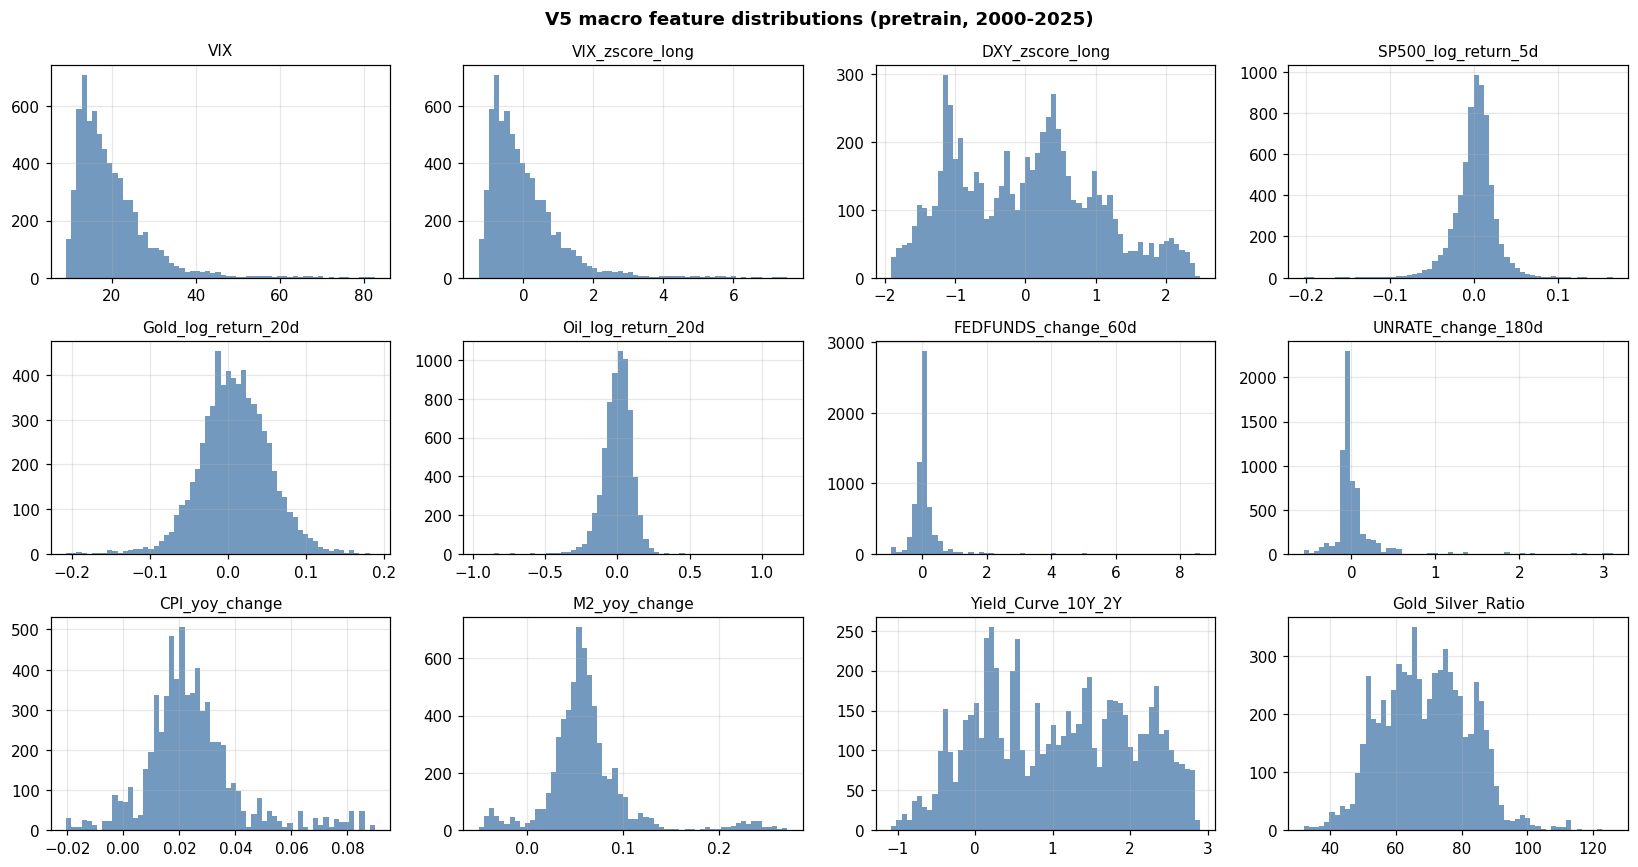

In [2]:
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
for ax, col in zip(axes.flat, pretrain.columns):
    pretrain[col].dropna().hist(ax=ax, bins=60, color="#4477aa", alpha=0.75)
    ax.set_title(col, fontsize=10)
fig.suptitle("V5 macro feature distributions (pretrain, 2000-2025)", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

## 2. Correlation matrix

12 derived features arasındaki Pearson korelasyon. Yüksek mutlak değerler (>0.7) feature redundancy işareti.

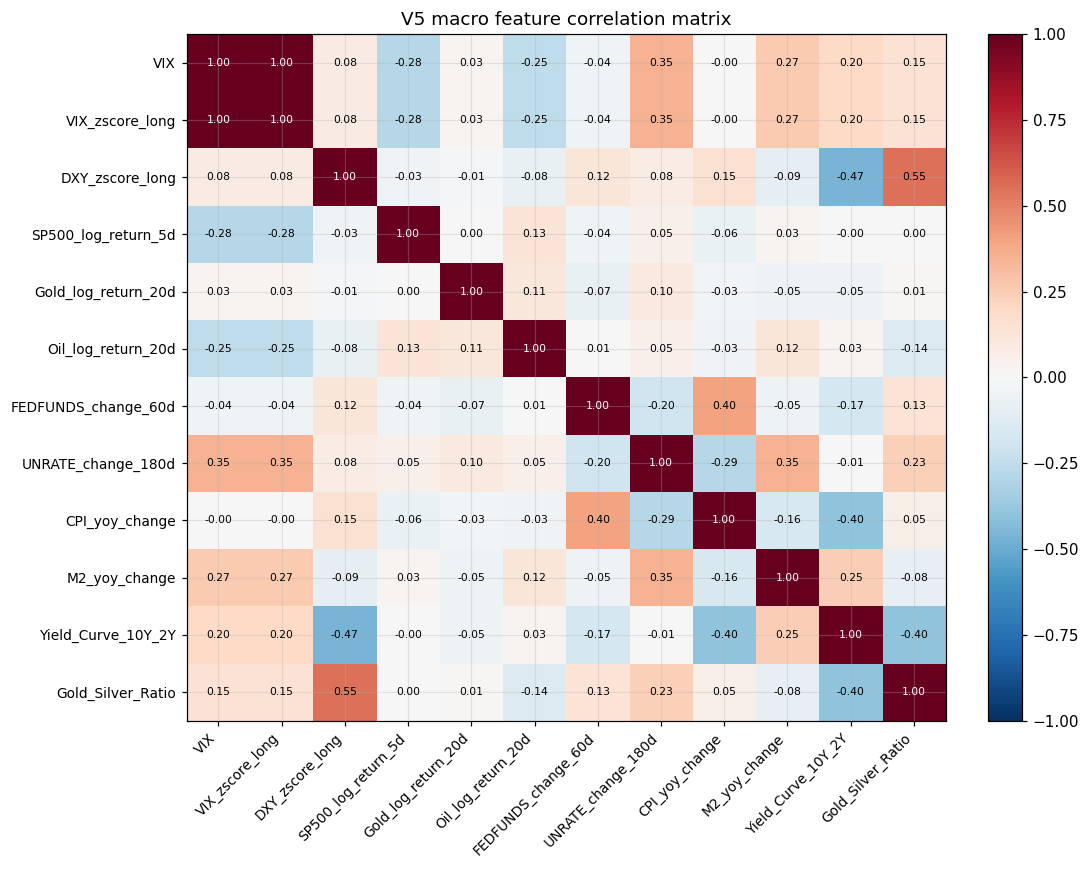

In [3]:
corr = pretrain.corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iat[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iat[i,j]) > 0.6 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("V5 macro feature correlation matrix")
plt.tight_layout(); plt.show()

## 3. Time-series overview (regime indicators)

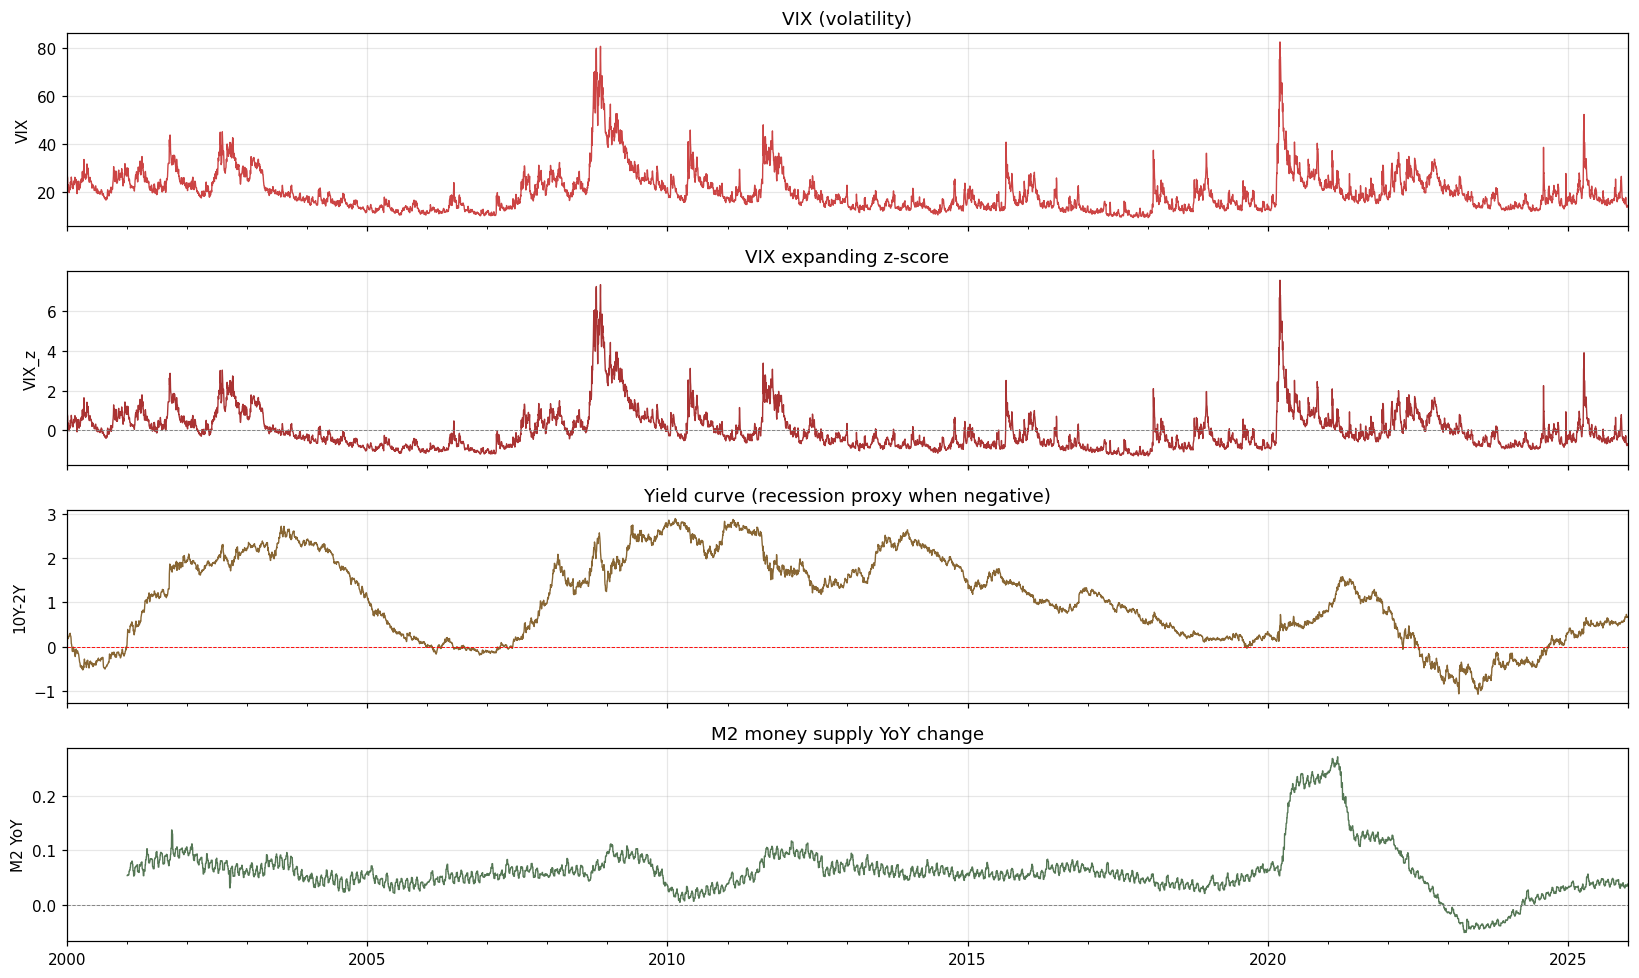

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(15, 9), sharex=True)
pretrain["VIX"].plot(ax=axes[0], color="#cc4444", lw=0.9); axes[0].set_ylabel("VIX"); axes[0].set_title("VIX (volatility)")
pretrain["VIX_zscore_long"].plot(ax=axes[1], color="#aa3333", lw=0.9); axes[1].axhline(0, color="grey", ls="--", lw=0.6); axes[1].set_ylabel("VIX_z"); axes[1].set_title("VIX expanding z-score")
pretrain["Yield_Curve_10Y_2Y"].plot(ax=axes[2], color="#886633", lw=0.9); axes[2].axhline(0, color="red", ls="--", lw=0.6); axes[2].set_ylabel("10Y-2Y"); axes[2].set_title("Yield curve (recession proxy when negative)")
pretrain["M2_yoy_change"].plot(ax=axes[3], color="#557755", lw=0.9); axes[3].axhline(0, color="grey", ls="--", lw=0.6); axes[3].set_ylabel("M2 YoY"); axes[3].set_title("M2 money supply YoY change")
fig.tight_layout(); plt.show()

## Summary

V5 macro feature set Stage 2 macro regime classifier (Composite FSM v5, Phase 2.12) için input olarak kullanılır.

Feature redundancy:
- VIX vs VIX_zscore_long: yüksek korelasyon, FSM `VIX_zscore_long` kullanır (ölçek normalizasyonu için)
- CPI_yoy vs M2_yoy: monetary policy farklı boyut, FSM ikisini de kullanır

Stage 1 (Trend, gelecek phase) BTC/ETH OHLCV-based feature seti kullanacak — bu macro feature'lar Stage 1'e DAHİL OLMAZ.